In [3]:
# Import libraries
import numpy as np
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import os
import geopandas as gpd
import cv2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, mean_squared_error, r2_score
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_geom
from rasterio.transform import Affine

In [66]:
#derived data products from paper
dtd = rasterio.open('/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_deadTreeDenisity_50m10km_forest.tif')
hs = rasterio.open('/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_hotspot_50m10km_forest.tif')
at = rasterio.open('/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_acquisitionTiming.tif')
ecc = rasterio.open('/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_eccentricity500m.tif')
crs = "EPSG:3857"
res = 1000.0

outputs = '/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/Revised data'
os.makedirs(outputs, exist_ok=True)

paths = [
    "/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_hotspot_50m10km_forest.tif",
    "/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_acquisitionTiming.tif",
    "/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_eccentricity500m.tif"
]

label_path = '/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_deadTreeDenisity_50m10km_forest.tif'

In [51]:
treedensity_2022 = dtd.read(1)
hotspot_2022 = hs.read(1)
print("Feature rasters:")
for p in paths: print(" -", p)
print("Label raster:", label_path)

Feature rasters:
 - /Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_deadTreeDenisity_50m10km_forest.tif
 - /Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_acquisitionTiming.tif
 - /Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_eccentricity500m.tif
Label raster: /Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_hotspot_50m10km_forest.tif


In [4]:
type(treedensity_2022)

numpy.ndarray

Text(0.5, 1.0, 'Tree Density')

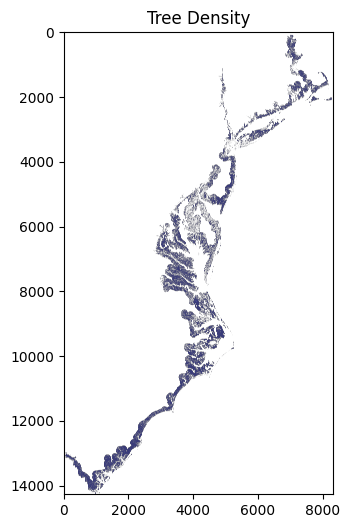

In [5]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(treedensity_2022, cmap='tab20b')
ax.set_title("Tree Density", fontsize=12)

In [7]:
hs_data = hs.read()
dtd_data = dtd.read()

hs_float = hs_data.astype(np.float32)
dtd_float = dtd_data.astype(np.float32)

hs = hs_float
dtd = dtd_float

In [29]:
#test
train_ds = tf.data.Dataset.from_tensors((X, y))
train_ds = train_ds.repeat()  # infinite stream of augmented whole images
train_ds = train_ds.map(lambda a,b: (tf.cast(a, tf.float32), tf.cast(b, tf.float32)))
train_ds = train_ds.map(lambda a,b: augment_tf(a,b), num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#val
val_ds = tf.data.Dataset.from_tensors((X, y)).repeat()
val_ds = val_ds.map(lambda a,b: (tf.cast(a, tf.float32), tf.cast(b, tf.float32)))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [30]:
target_h, target_w = model.input_shape[1], model.input_shape[2]
X_resized = tf.image.resize(X.astype('float32'), (target_h, target_w)).numpy()
print("Resized to:", X_resized.shape)

Resized to: (572, 572, 8332)


Shapes: X = (14271, 8332, 3)  Y = (14271, 8332)


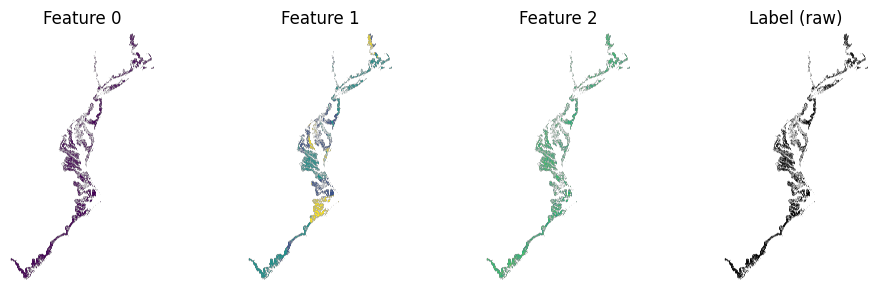

In [73]:
def load_and_stack(feature_paths, label_path, resampling=Resampling.nearest):
    with rasterio.open(label_path) as ref:
        ref_arr = ref.read(1).astype(np.float32)
        H, W = ref.height, ref.width
        ref_transform = ref.transform

    stacks = []
    for p in feature_paths:
        with rasterio.open(p) as src:
            if src.width == W and src.height == H and src.transform == ref_transform:
                arr = src.read(1).astype(np.float32)
            else:
                arr = src.read(
                    1,
                    out_shape=(H, W),
                    resampling=resampling
                ).astype(np.float32)
        stacks.append(arr)

    X = np.stack(stacks, axis=-1)
    Y = ref_arr
    return X, Y

X, Y = load_and_stack(paths, label_path)
print("Shapes: X =", X.shape, " Y =", Y.shape)

# Visualize
plt.figure(figsize=(10,3))
for i in range(X.shape[-1]):
    plt.subplot(1, X.shape[-1] + 1, i+1)
    plt.imshow(X[...,i], cmap='viridis'); plt.title(f"Feature {i}"); plt.axis('off')

plt.subplot(1, X.shape[-1]+1, X.shape[-1]+1)
plt.imshow(Y, cmap='gray'); plt.title("Label (raw)"); plt.axis('off')
plt.tight_layout(); plt.show()

In [109]:
# ---- Preprocess label for regression ----
def preprocess_label_regression(Y, do_log=True):
    # Convert to float and optionally log-transform (small eps to avoid log(0))
    Yf = Y.astype(np.float32)
    if do_log:
        eps = 1e-6
        Yf = np.log(Yf + eps)
        print("Applied log-transform to label. min/max:", Yf.min(), Yf.max())
    else:
        print("Using raw label values. min/max:", Yf.min(), Yf.max())
    return Yf

# If you want raw values, set do_log=False
Y_reg = preprocess_label_regression(Y, do_log=True)

# extract patches (labels are continuous floats)
def extract_patches_regression(X, Y, patch_size=64, stride=64):
    H, W, C = X.shape
    patches_X, patches_Y = [], []
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            xp = X[y:y+patch_size, x:x+patch_size, :]
            yp = Y[y:y+patch_size, x:x+patch_size]
            if np.any(np.isnan(xp)) or np.any(np.isnan(yp)):
                continue
            patches_X.append(xp)
            patches_Y.append(yp)
    patches_X = np.array(patches_X).astype(np.float32)
    patches_Y = np.array(patches_Y).astype(np.float32)[..., np.newaxis]  # (N,H,W,1)
    return patches_X, patches_Y

patches_X, patches_Y = extract_patches_regression(X, Y_reg, patch_size=PATCH_SIZE, stride=STRIDE)
print("Regression patches:", patches_X.shape, patches_Y.shape)



Applied log-transform to label. min/max: nan nan
Regression patches: (1051, 16, 16, 3) (1051, 16, 16, 1)


In [110]:
MAX_PATCHES = 64
if patches_X.shape[0] > MAX_PATCHES:
    idx = np.random.choice(patches_X.shape[0], MAX_PATCHES, replace=False)
    patches_X = patches_X[idx]; patches_Y = patches_Y[idx]

patches_X = patches_X.astype(np.float32)
patches_Y = patches_Y.astype(np.uint8)[..., np.newaxis]

X_train, X_tmp, Y_train, Y_tmp = train_test_split(
    patches_X, patches_Y, test_size=0.5, random_state=42
)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_tmp, Y_tmp, test_size=0.55, random_state=42
)

print("Split sizes:", len(X_train), len(X_val), len(X_test))

def make_dataset(X, Y, batch=10, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    ds = ds.map(lambda a,b: (tf.cast(a, tf.float32), tf.cast(b, tf.float32)))
    if shuffle: ds = ds.shuffle(200)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train, Y_train)
val_ds   = make_dataset(X_val, Y_val, shuffle=False)
test_ds  = make_dataset(X_test, Y_test, shuffle=False)


Split sizes: 32 14 18


In [114]:
def simple_unet(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPool2D()(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPool2D()(c2)

    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPool2D()(c3)

    # Bottleneck
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(p3)
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(b)

    # Decoder
    u3 = layers.UpSampling2D()(b)
    u3 = layers.Concatenate()([u3, c3])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u3)
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.Concatenate()([u2, c2])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(c5)

    u1 = layers.UpSampling2D()(c5)
    u1 = layers.Concatenate()([u1, c1])
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(c6)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)

    return models.Model(inputs, outputs)

model = simple_unet((PATCH_SIZE, PATCH_SIZE, X.shape[-1]))
model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4), loss='mse', metrics=['accuracy'])
model.summary()


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 16, 16, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_178 (Conv2D) │ (None, 16, 16,    │        896 │ input_layer_13[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_179 (Conv2D) │ (None, 16, 16,    │      9,248 │ conv2d_178[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_38    │ (None, 8, 8, 32)  │          0 │ conv2d_179[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_180 (Conv2D) │ (None, 8, 8, 64)  │     18,496 │ max_pooling2d_38… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_181 (Conv2D) │ (None, 8, 8, 64)  │     36,928 │ conv2d_180[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_39    │ (None, 4, 4, 64)  │          0 │ conv2d_181[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_182 (Conv2D) │ (None, 4, 4, 128) │     73,856 │ max_pooling2d_39… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_183 (Conv2D) │ (None, 4, 4, 128) │    147,584 │ conv2d_182[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_40    │ (None, 2, 2, 128) │          0 │ conv2d_183[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_184 (Conv2D) │ (None, 2, 2, 256) │    295,168 │ max_pooling2d_40… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_185 (Conv2D) │ (None, 2, 2, 256) │    590,080 │ conv2d_184[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_34    │ (None, 4, 4, 256) │          0 │ conv2d_185[0][0]  │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_36      │ (None, 4, 4, 384) │          0 │ up_sampling2d_34… │
│ (Concatenate)       │                   │            │ conv2d_183[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_186 (Conv2D) │ (None, 4, 4, 128) │    442,496 │ concatenate_36[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_187 (Conv2D) │ (None, 4, 4, 128) │    147,584 │ conv2d_186[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_35    │ (None, 8, 8, 128) │          0 │ conv2d_187[0][0]  │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_37      │ (None, 8, 8, 192) │          0 │ up_sampling2d_35… │
│ (Concatenate)       │                   │            │ conv2d_181[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_188 (Conv2D) │ (None, 8, 8, 64)  │    110,656 │ concatenate_37[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_189 (Conv2D) │ (None, 8, 8, 64)  │     36,928 │ conv2d_188[0][0]

 Total params: 1,946,881 (7.43 MB)

 Trainable params: 1,946,881 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

In [115]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(os.path.join(outputs, "best_model_reg.h5"),
                                       save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
]

history = model.fit(train_ds, epochs=12, validation_data=val_ds, callbacks=callbacks)


Epoch 1/12
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0000e+00 - loss: 53002.6875

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.0000e+00 - loss: 53931.1367 - val_accuracy: 0.0000e+00 - val_loss: 52167.2227
Epoch 2/12
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0000e+00 - loss: 55815.0664

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0000e+00 - loss: 53878.8281 - val_accuracy: 0.0000e+00 - val_loss: 52121.4922
Epoch 3/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0000e+00 - loss: 53804.0898

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0000e+00 - loss: 53830.6055 - val_accuracy: 0.0000e+00 - val_loss: 52091.2930
Epoch 4/12
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0000e+00 - loss: 55394.8398

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0000e+00 - loss: 53796.0312 - val_accuracy: 0.0000e+00 - val_loss: 52079.5078
Epoch 5/12
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0000e+00 - loss: 54494.5898

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0000e+00 - loss: 53783.7500 - val_accuracy: 0.0000e+00 - val_loss: 52077.2578
Epoch 6/12
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0000e+00 - loss: 54464.5039

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0000e+00 - loss: 53781.7812 - val_accuracy: 0.0000e+00 - val_loss: 52076.9961
Epoch 7/12
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0000e+00 - loss: 54770.4102

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0000e+00 - loss: 53781.4844 - val_accuracy: 0.0000e+00 - val_loss: 52076.9727
Epoch 8/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0000e+00 - loss: 53781.4492 - val_accuracy: 0.0000e+00 - val_loss: 52076.9727
Epoch 9/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0000e+00 - loss: 53781.4531 - val_accuracy: 0.0000e+00 - val_loss: 52076.9727
Epoch 10/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0000e+00 - loss: 53781.4492 - val_accuracy: 0.0000e+00 - val_loss: 52076.9727
Epoch 11/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0000e+00 - loss: 53781.4531 - val_accuracy: 0.0000e+00 - val_loss: 52076.9727
Epoch 12/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0000e+00 - loss: 53781.4492 - val_accuracy: 0.0000e+00 - val_loss: 52076.9727


In [117]:
# Predict on test set
y_pred = model.predict(test_ds)  # shape (N,H,W,1)
y_true = np.concatenate([y for x,y in test_ds], axis=0)

yp = y_pred.flatten()
yt = y_true.flatten()

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(yt, yp)
rmse = np.sqrt(mse)
mae = mean_absolute_error(yt, yp)
r2 = r2_score(yt, yp)

print("RMSE:", rmse)
print("MAE:", mae)
print("R^2:", r2)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
RMSE: 240.4457936573231
MAE: 238.91427612304688
R^2: -76.46023559570312


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Pixel Accuracy: 0.0
Balanced Accuracy: 0.0
IoU: 0.0
Confusion Matrix:
 [[   0   59    0]
 [   0    0    0]
 [   0 4549    0]]


/opt/anaconda3/envs/tf/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


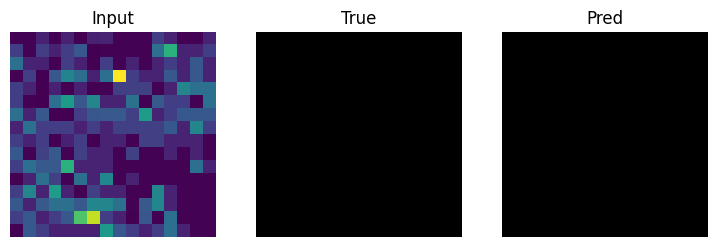

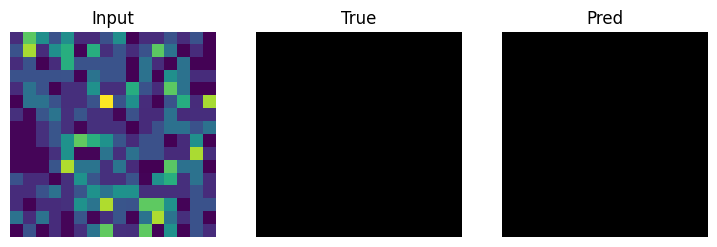

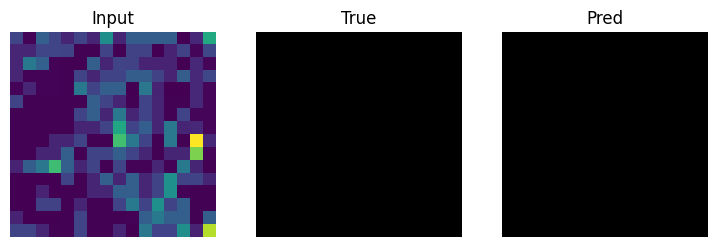

In [118]:
y_pred = model.predict(test_ds)
y_pred_bin = (y_pred > 0.5).astype(np.uint8)

Y_test_arr = np.concatenate([y for x,y in test_ds], axis=0)

y_true = Y_test_arr.flatten()
y_pred_f = y_pred_bin.flatten()

acc = accuracy_score(y_true, y_pred_f)
bal = balanced_accuracy_score(y_true, y_pred_f)
cm  = confusion_matrix(y_true, y_pred_f)

intersection = np.logical_and(y_true==1, y_pred_f==1).sum()
union = np.logical_or(y_true==1, y_pred_f==1).sum()
iou = intersection / union if union else 0

print("Pixel Accuracy:", acc)
print("Balanced Accuracy:", bal)
print("IoU:", iou)
print("Confusion Matrix:\n", cm)

# Show a few examples
for i in range(3):
    plt.figure(figsize=(9,3))
    plt.subplot(1,3,1); plt.imshow(X_test[i].sum(axis=2)); plt.title("Input"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(Y_test[i,...,0], cmap='gray'); plt.title("True"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(y_pred_bin[i,...,0], cmap='gray'); plt.title("Pred"); plt.axis('off')
    plt.show()


In [69]:
#improvments

In [5]:

# Flatten predictions and true labels
y_true_flat = Y_test_arr.flatten()
y_pred_flat = y_pred_bin.flatten()

# Compute confusion matrix
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=[0,1])
print("Confusion matrix:\n", cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-hotspot (0)", "Mortlaity Hotspot (1)"])
plt.figure(figsize=(5,5))
disp.plot(values_format='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

NameError: name 'y_true' is not defined

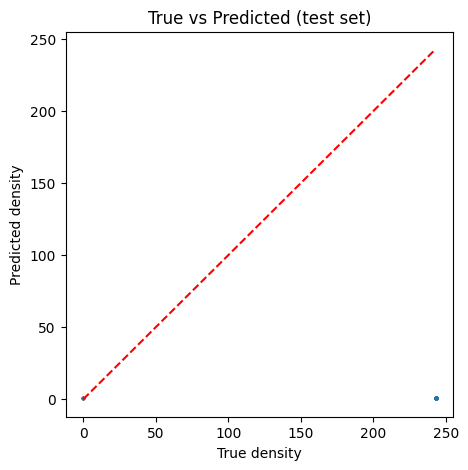

In [89]:
plt.figure(figsize=(5,5))
plt.scatter(yt, yp, s=2, alpha=0.3)
mn = min(yt.min(), yp.min()); mx = max(yt.max(), yp.max())
plt.plot([mn,mx], [mn,mx], 'r--')
plt.xlabel("True density"); plt.ylabel("Predicted density")
plt.title("True vs Predicted (test set)")
plt.show()


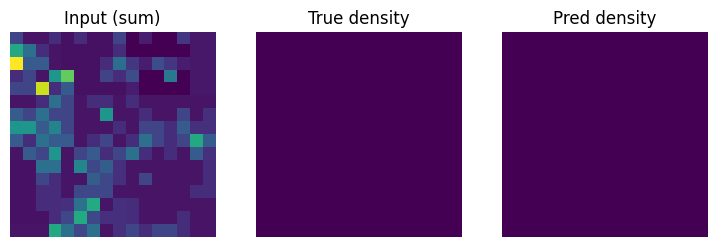

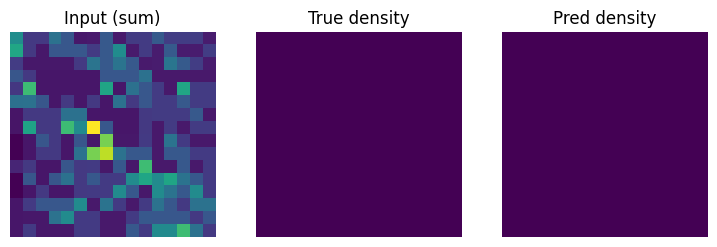

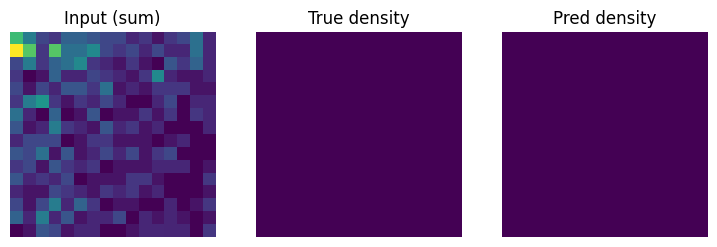

In [91]:
n_show = 3
for i in range(n_show):
    plt.figure(figsize=(9,3))
    plt.subplot(1,3,1); plt.imshow(X_test[i].sum(axis=2)); plt.title("Input (sum)"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(y_true[i,...,0], cmap='viridis'); plt.title("True density"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(y_pred[i,...,0], cmap='viridis'); plt.title("Pred density"); plt.axis('off')
    plt.show()

Confusion matrix:
 [[ 0 78]
 [ 0  0]]


<Figure size 500x500 with 0 Axes>

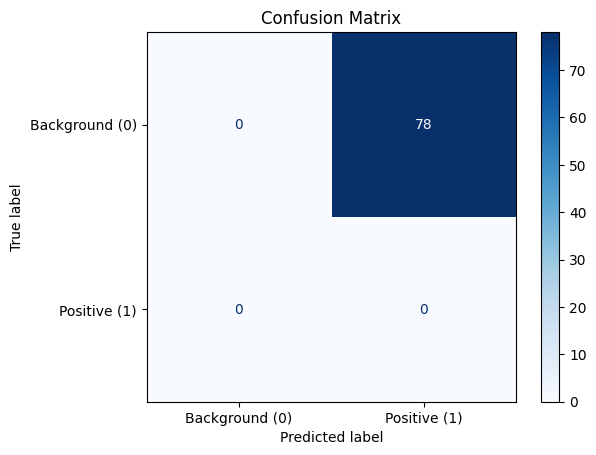

In [93]:

# Flatten predictions and true labels
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()

# Compute confusion matrix
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=[0,1])
print("Confusion matrix:\n", cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Background (0)", "Positive (1)"])
plt.figure(figsize=(5,5))
disp.plot(values_format='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()